<h1> <center><font color='blue'> Modeling the Impact of Generative AI on Domain Learning and Innovation

<h2><font color='teal'><center> Venki Uddameri, Ph.D., P.E.

<hr style="border: none; height: 4px; background: #333;">

<h3> Background:

There is considerable debate regarding the use of Gen AI in classrooms.  One camp advocates a full integration of Gen AI tools to scaffold student learning.  They contend Gen AI is here to stay, and students use it regardless of any  policies forbidding their use, so adoption may lead to better (ethical) ways of using it.  The other camp, is concerned about how Gen AI tools may impact critical thinking in students and reinforce the belief that all they have to do is search for the answers rather than applying their mind.  They advocate using traditional testing methods such as closed book exams and oral testing.  

Clearly, both these approaches have merit.  In many cases, a deep knowledge is not required to solve a problem and the solutions of Gen AI are sufficient to move things along.  However, Gen AI is based on past knowledge, so it may not be able to predict correct solutions (hallucinations).  More importantly, what can be extracted out of Gen AI depends upon how deeply you engage with it.  Such deep engagement requires domain expertise.  So can students who have come to rely on Gen AI go beyond what Gen AI has to offer? is critical to understand the progress of a subject domain.

<h3> Conceptual Model

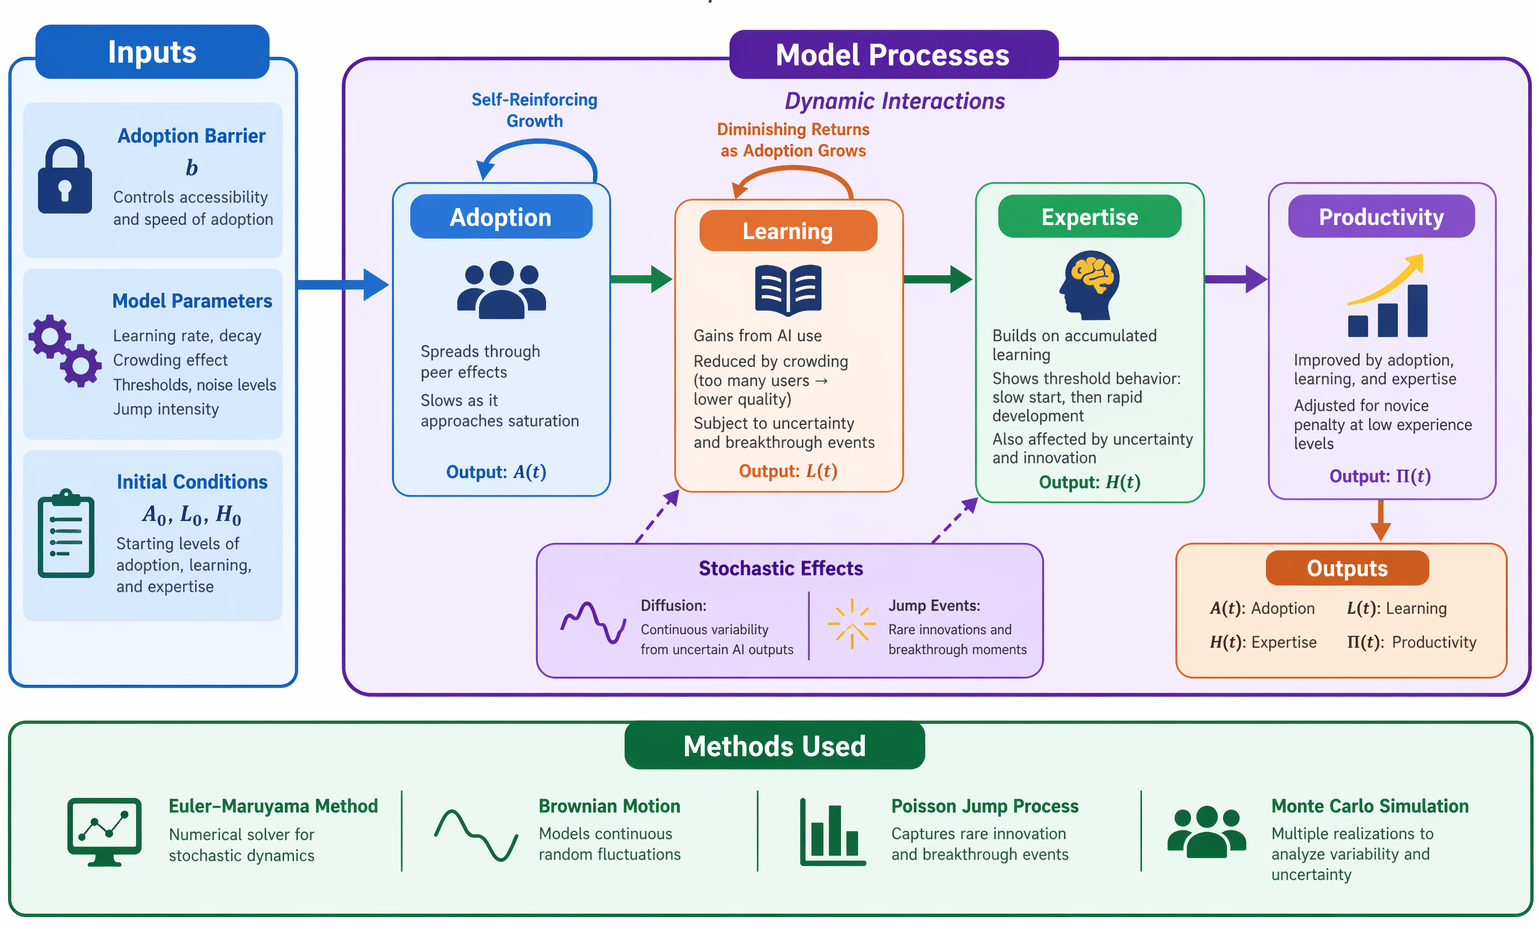

The model seeks to implement four processes - 1) The rate of **Adoption** of Gen AI tools (modeled using a logistic function) and impacted by an adoption barrier parameter (b).  The **Learning Process** focuses on gains from using AI, but also accounts for dissemination of incorrect knowledge (uncertainty in information and prediction limitations of AI).  It also models breakthrough events that AI could trigger in certain individuals (much akin to mutations in genetic evolution).  **Expertise** is the progression from possessing domain information to thinking at a deeper level.  This depends upon **learning**, but also requires sustained engagement with the subject material before seeing results (thresholding effects).  Finally an integated **Productivity** metric is used to model productivity gains as a function of adoption, learning and expertise.  A novice penalty is included to account for contributions stemming from low experience levels (that adds little useful information and perhaps a lot more uncertainty of the overall knowledge base).  The model uses Brownian motion for diffusion of learning and Poisson jump processes to capture rare innovation and breakthrough events.  As the model is more **normative** (idea-driven) than **positive** (data driven), Monte Carlo simulations are used to capture the insights under parametric uncertainty.   

<h3> Mathematical Model

The adoption (A), learning (L), and expertise dynamics (H) together form a coupled stochastic dynamical system given by:

$\frac{dA}{dt} = r_0 e^{-\lambda b} A \left(1 - \frac{A}{A_{\max}} \right)$


$dL = \left[\mu(1-\eta A) - \delta L \right]dt + g_L(A,L,H)\,dW_L + \Delta L\, dJ_t$


$ dH = \left[\beta(H)L(1-H) - \gamma H \right]dt + g_H(A,L,H)\,dW_H + \Delta H\, dJ_t$

where $A(t)$ represents the level of adoption of generative AI tools, $L(t)$ denotes the accumulated learning stock, and $H(t)$ represents the fraction of learners achieving expertise. The system is coupled through the dependence of learning on adoption ($A$), and the dependence of expertise formation on learning ($L$).

The stochastic terms $dW_L$ and $dW_H$ represent Wiener processes capturing continuous variability in learning and expertise, respectively \cite{oksendal2003}, while $dJ_t$ represents a Poisson jump process capturing rare but high-impact innovation events \cite{applebaum2009}. The functions $g_L(A,L,H)$ and $g_H(A,L,H)$ define the state-dependent intensity of stochastic fluctuations.

The interaction between learning and expertise formation is defined using $\Pi(L,H)$ defined as:

$
\Pi(t) = \frac{A(t)}{1 + \chi e^{-\rho b}} 
\left[ P_{\min} + \left(P_{\max} - P_{\min}\right)
\left(1 - e^{-\alpha H(t) L(t)}\right) \right]
$

In this formulation, $P_{\min}$ and $P_{\max}$ represent the minimum and maximum attainable productivity levels, respectively, while $\alpha$ controls the rate at which productivity saturates with increasing knowledge and expertise. The multiplicative term $H L$ reflects the interaction between accumulated knowledge and skill level, ensuring that productivity gains are limited when either component is low.

The denominator term $1 + \chi e^{-\rho b}$ introduces a novice penalty, where $\chi$ represents the magnitude of inefficiency associated with low-expertise users, and $\rho$ controls the sensitivity of this penalty to the adoption barrier $b$. Lower barriers to adoption increase participation but may also increase the proportion of novice users, thereby reducing overall gains in efficiency (i.e.,  going above and beyond to find a better solution to the problem at hand).

The productivity function captures a fundamental tradeoff in generative AI–mediated systems: while increased adoption enhances access and potential output, it may also introduce inefficiencies when users lack sufficient expertise to effectively utilize the technology. As expertise increases, this penalty diminishes, allowing the system to transition toward higher productivity regimes.

This formulation enables the evaluation of system-level outcomes and provides a bridge between individual learning dynamics and aggregate performance, making it particularly useful for assessing the broader impact of generative AI in educational and engineering contexts.

The mathematical model includes one deterministic (adoption) and two stochastic differential equations (learning and expertise) and one stochastic algebraic equation (productivity).  The **Euler-Maruyama method** was used to solve the system of equations. 


<h3> Code

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Input Model Parameters
params = {
    "r0": 1.2,
    "lam": 3.0,
    "Amax": 0.85,

    "mu": 0.35,
    "eta": 0.60,
    "delta": 0.20,
    "sigma_L": 0.60,
    "kappa_L": 0.30,

    "beta0": 1.40,
    "k": 20.0,
    "Hc": 0.22,
    "gamma": 0.08,
    "sigma_H": 0.40,
    "kappa_H": 0.50,

    "Pmin": 0.20,
    "Pmax": 2.50,
    "alpha": 1.80,

    "chi": 0.70,
    "rho": 2.50,

    "noise_floor_L": 0.20,
    "noise_floor_H": 0.15,

    "lambda0": 0.02,
    "lambda1": 0.25,
    "jump_L_scale": 0.30,
    "jump_H_scale": 0.15
}


In [31]:
# Define functions for use in the model

def r_of_b(b, p):
    return p["r0"] * np.exp(-p["lam"] * b)

def beta_of_H(H, p):
    return p["beta0"] / (1 + np.exp(-p["k"] * (H - p["Hc"])))

def novice_penalty(b, p):
    return p["chi"] * np.exp(-p["rho"] * b)

def productivity(L, H, p):
    return p["Pmin"] + (p["Pmax"] - p["Pmin"]) * (1 - np.exp(-p["alpha"] * H * L))

def gL(A, L, H, p):
    return p["sigma_L"] * (
        p["noise_floor_L"] + A * (1 - H) * np.exp(-p["kappa_L"] * L)
    )

def gH(A, L, H, p):
    return p["sigma_H"] * (
        p["noise_floor_H"] + A * (1 - H) * np.exp(-p["kappa_H"] * H)
    )


In [32]:
# Function to solve the system of equations
# Note time-stepp is 0.005 and T=40 by default (change as necessary(
def simulate(b, p, T=40, dt=0.005, seed=None):
    rng = np.random.default_rng(seed)

    n = int(T / dt)
    t = np.linspace(0, T, n)

    A = np.zeros(n)
    L = np.zeros(n)
    H = np.zeros(n)
    Pi = np.zeros(n)

    A[0], L[0], H[0] = 0.03, 0.05, 0.04

    penalty = novice_penalty(b, p)

    for i in range(n - 1):

        dW_L = np.sqrt(dt) * rng.standard_normal()
        dW_H = np.sqrt(dt) * rng.standard_normal()

        r = r_of_b(b, p)
        mu_eff = max(0, p["mu"] * (1 - p["eta"] * A[i]))
        beta = beta_of_H(H[i], p)

        dA = r * A[i] * (1 - A[i] / p["Amax"]) * dt

        gL_i = gL(A[i], L[i], H[i], p)
        gH_i = gH(A[i], L[i], H[i], p)

        dL = (mu_eff - p["delta"] * L[i]) * dt + gL_i * dW_L
        dH = (beta * L[i] * (1 - H[i]) - p["gamma"] * H[i]) * dt + gH_i * dW_H

        # Mutation jumps
        lam_t = p["lambda0"] + p["lambda1"] * A[i]
        if rng.random() < lam_t * dt:
            dL += p["jump_L_scale"] * np.exp(rng.normal(0, 0.5))
            dH += p["jump_H_scale"] * np.exp(rng.normal(0, 0.5))

        A[i+1] = np.clip(A[i] + dA, 0, p["Amax"])
        L[i+1] = max(L[i] + dL, 0)
        H[i+1] = np.clip(H[i] + dH, 0, 1)

        Pi[i] = A[i] * productivity(L[i], H[i], p) / (1 + penalty)

    return t, A, L, H, Pi


In [33]:
# Plotting functions for a single plot
def plot_single(barriers, labels):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    for b, label in zip(barriers, labels):
        t, A, L, H, Pi = simulate(b, params, seed=42)

        axs[0,0].plot(t, A, label=label)
        axs[0,1].plot(t, L, label=label)
        axs[1,0].plot(t, H, label=label)
        axs[1,1].plot(t, Pi, label=label)

    axs[0,0].set_title("Adoption(t)")
    axs[0,1].set_title("Learning (t)")
    axs[1,0].set_title("Expertise Development(t)")
    axs[1,1].set_title("Overall Productivity (t)")
    axs[1,1].set_xlabel('Time Horizon')
    axs[1,0].set_xlabel('Time Horizon')

    for ax in axs.flat:
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()
    # return (t, A, L, H, Pi)  # returns the computed values
    return None # only plots the figure

In [34]:
# Plot across multiple barriers
def plot_multiple(barriers, labels):
    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    for b, label in zip(barriers, labels):
        for i in range(6):
            t, A, L, H, Pi = simulate(b, params, seed=i)

            axs[0].plot(t, L, alpha=0.4, label=label if i==0 else "")
            axs[1].plot(t, H, alpha=0.4, label=label if i==0 else "")
            axs[2].plot(t, Pi, alpha=0.4, label=label if i==0 else "")

    axs[0].set_title("Learning Stock (multiple runs)")
    axs[1].set_title("High Skill Fraction")
    axs[2].set_title("Productivity")

    for ax in axs:
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()
    return None

In [35]:
# Mean + band plot
def plot_mean(barriers, labels):
    plt.figure(figsize=(10,6))

    for b, label in zip(barriers, labels):
        all_pi = []

        for i in range(30):
            _, _, _, _, Pi = simulate(b, params, seed=i)
            all_pi.append(Pi)

        all_pi = np.array(all_pi)
        mean = all_pi.mean(axis=0)
        lo = np.percentile(all_pi, 10, axis=0)
        hi = np.percentile(all_pi, 90, axis=0)

        t = np.linspace(0, 40, len(mean))

        plt.plot(t, mean, label=f"{label} mean")
        plt.fill_between(t, lo, hi, alpha=0.2)

    plt.title("Mean Productivity with Variability")
    plt.xlabel("Time")
    plt.ylabel("Productivity")
    plt.legend()
    plt.grid(True)
    plt.show()
    return None

In [36]:
# Function to make plots
def main():
    barriers = [0.1, 0.35, 0.7]
    labels = ["Low", "Moderate", "High"]

    plot_single(barriers, labels)
    plot_multiple(barriers, labels)
    plot_mean(barriers, labels)
    return None


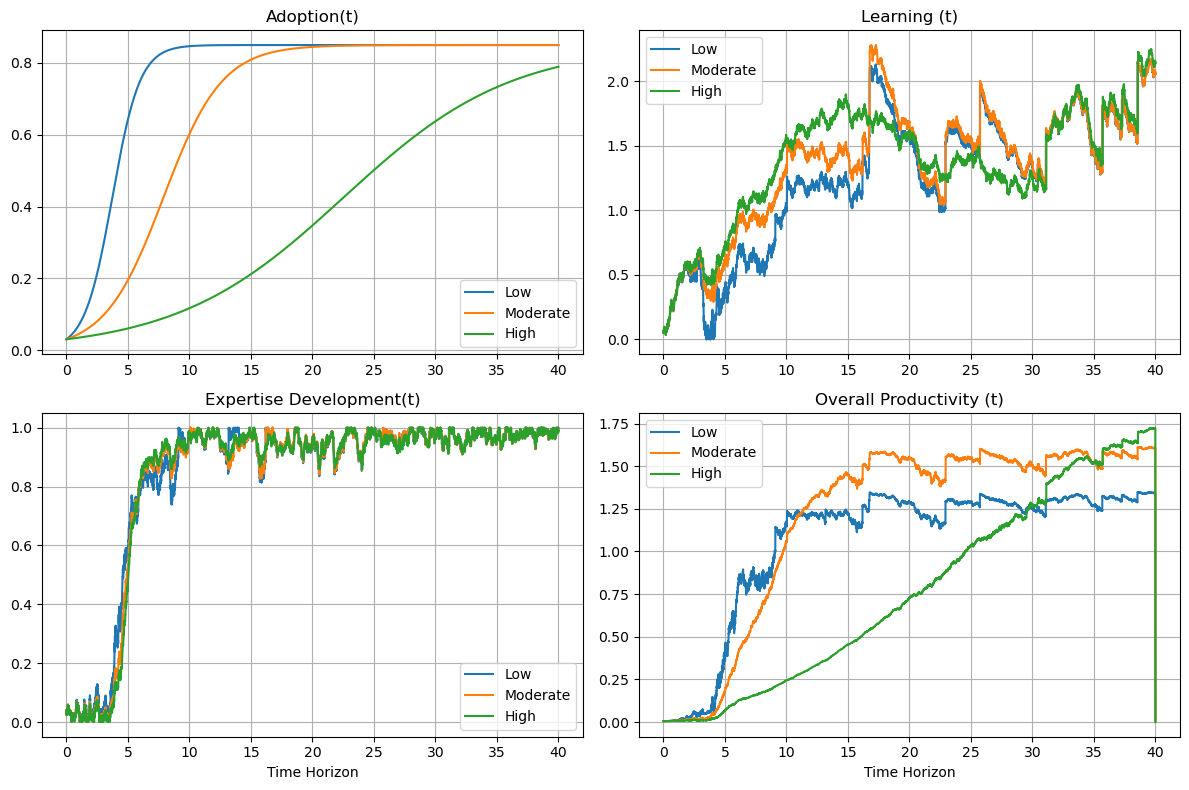

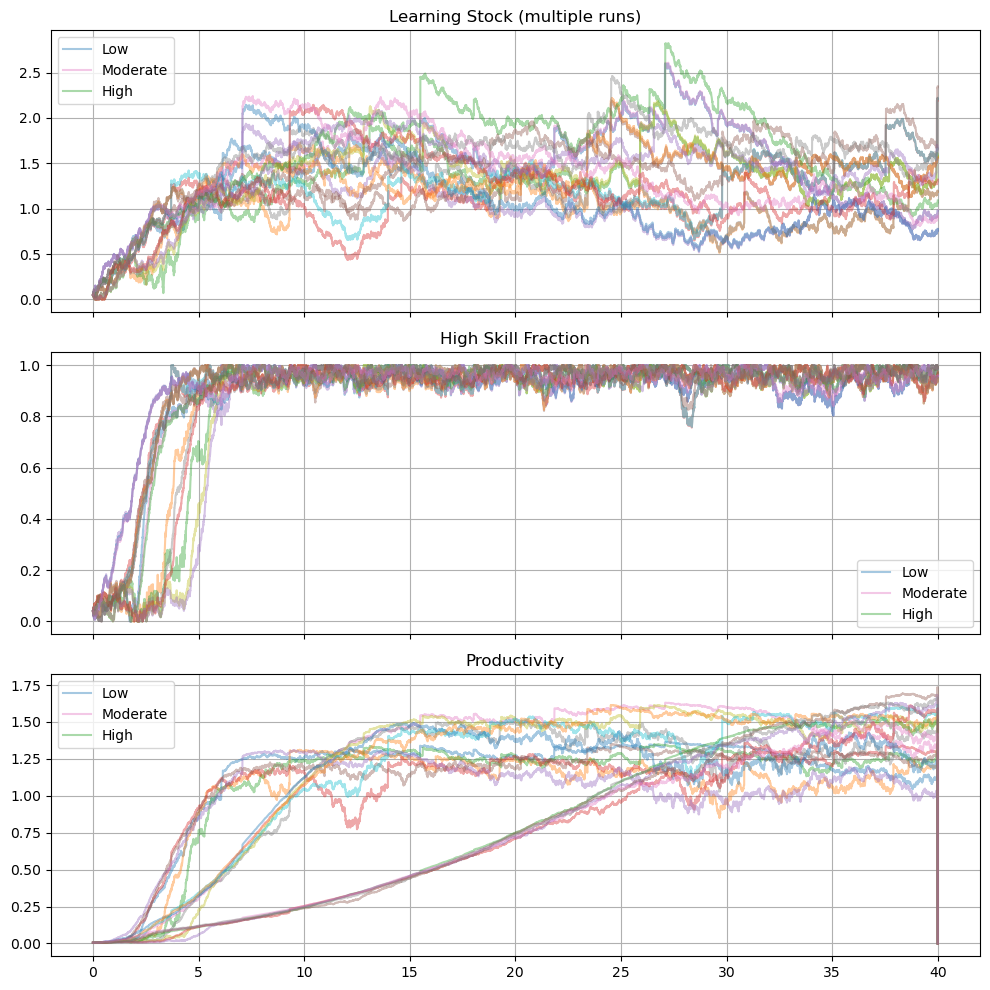

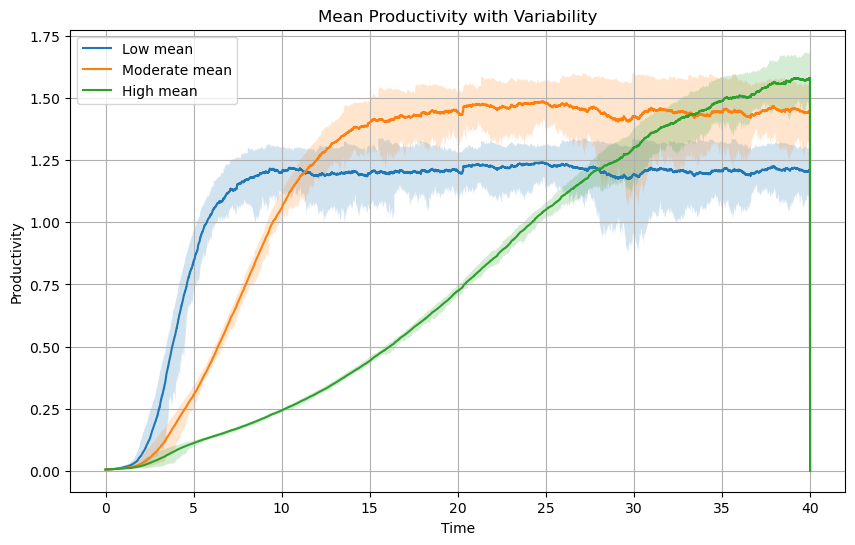

In [37]:
# Run the model
if __name__ == "__main__":
    main()  # call main which calls other functions; Remove if only functions are to be imported

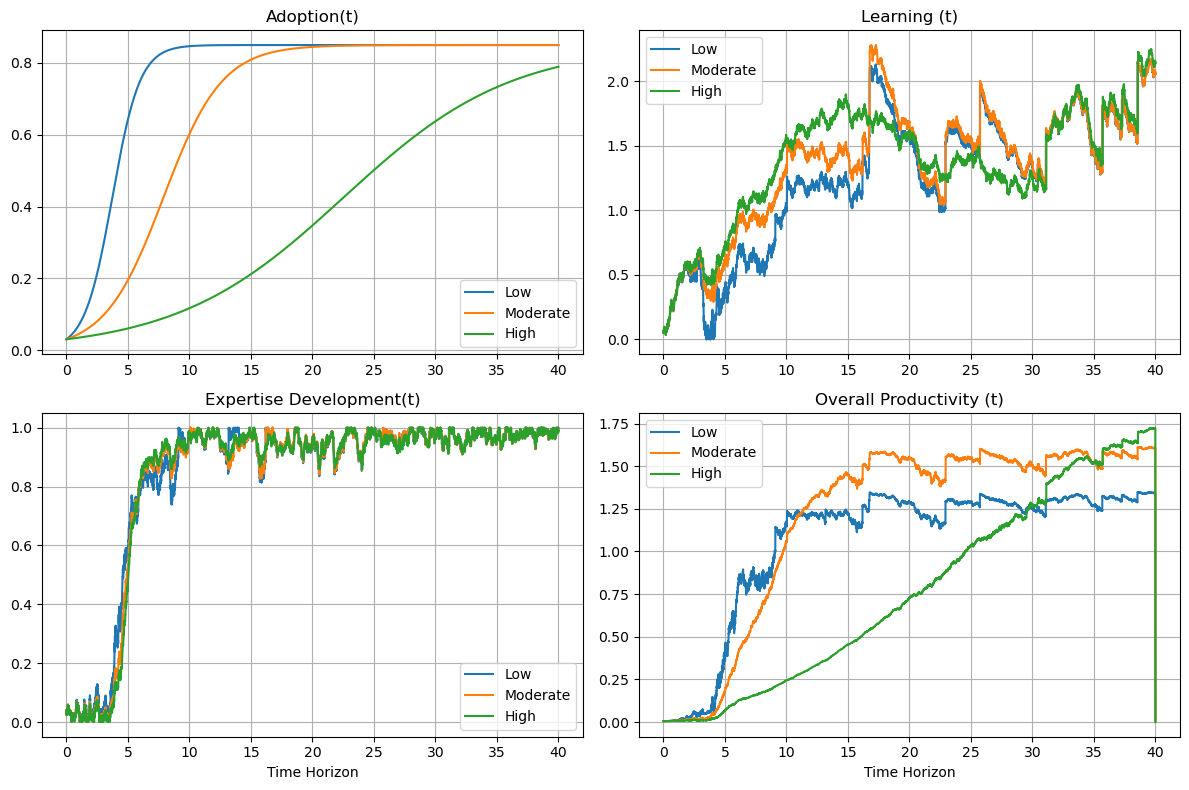

In [39]:
barriers = [0.1, 0.35, 0.7]
labels = ["Low", "Moderate", "High"]
plot_single(barriers, labels)